## kNN

Implement the k-Nearest Neighbors (kNN) algorithm and apply it to the Iris dataset (https://archive.ics.uci.edu/dataset/53/iris). Implement data normalization if necessary (if not, explain why). To test the algorithm, use both standard train-test splitting and 10-fold cross-validation.

- Data must be normalizaed and cleaned from outliers so all features contribute equally to the distance calculation.
- Thumb rule - best k ~ sqrt(N), where N is all data

### Main steps:

1. Data Preparation:  
   - Download and review the Iris dataset from the provided link.  
   - Ensure that the data is correctly loaded into your program.

In [ ]:
%pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
iris = fetch_ucirepo(id=53)

# data (as pandas dataframes)
X = iris.data.features
y = iris.data.targets


# metadata
print(iris.metadata)

# variable information
print(iris.variables)

In [3]:
import pandas as pd
import numpy as np

In [4]:
X.head(3)

,sepal length,sepal width,petal length,petal width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [5]:
y.head(3)

,class
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa


In [6]:
df = pd.concat([X, y], axis=1)
# df.to_csv("iris.csv", index=False)
df

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [7]:
import matplotlib.pyplot as plt

<Axes: >

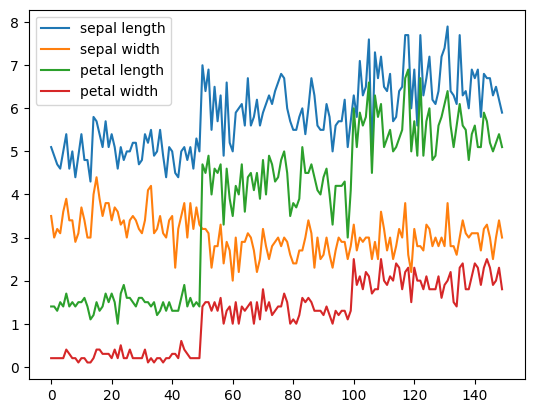

In [8]:
df.plot()

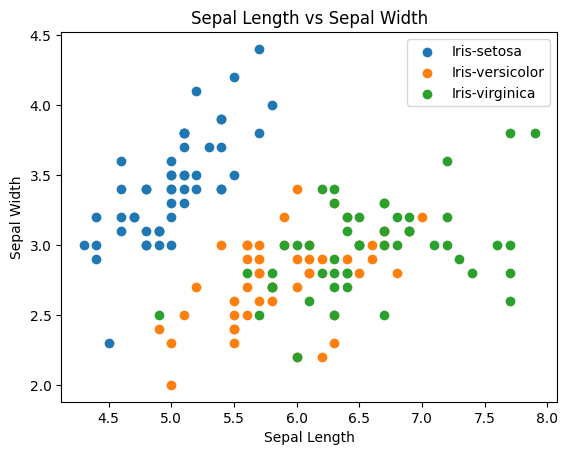

In [9]:
def plot_sepal(X, y):
    df = pd.concat([X, y], axis=1)

    for cls in df["class"].unique():
        subset = df[df["class"] == cls]

        plt.scatter(subset["sepal length"], subset["sepal width"], label=cls)

    plt.title("Sepal Length vs Sepal Width")

    plt.xlabel("Sepal Length")

    plt.ylabel("Sepal Width")

    plt.legend()

    plt.show()


plot_sepal(X, y)

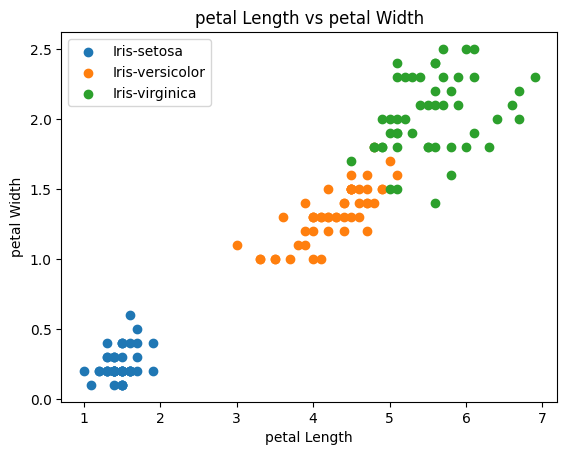

In [10]:
def plot_petal(X, y):
    df = pd.concat([X, y], axis=1)

    for cls in df["class"].unique():
        subset = df[df["class"] == cls]

        plt.scatter(subset["petal length"], subset["petal width"], label=cls)

    plt.title("petal Length vs petal Width")

    plt.xlabel("petal Length")

    plt.ylabel("petal Width")

    plt.legend()

    plt.show()


plot_petal(X, y)

2. Preprocessing:  
   - If necessary, apply data normalization (e.g., Min-Max scaling or Z-score normalization).  
   - Justify your choice: explain when normalization is needed and what advantages it provides for kNN.

In [11]:
X_minmax = X.copy()
for column in X_minmax.columns:
    X_minmax[column] = (X_minmax[column] - X_minmax[column].min()) / (X_minmax[column].max() - X_minmax[column].min())

X_minmax

,sepal length,sepal width,petal length,petal width
0,0.222222,0.625000,0.067797,0.041667
1,0.166667,0.416667,0.067797,0.041667
2,0.111111,0.500000,0.050847,0.041667
3,0.083333,0.458333,0.084746,0.041667
4,0.194444,0.666667,0.067797,0.041667
...,...,...,...,...
145,0.666667,0.416667,0.711864,0.916667
146,0.555556,0.208333,0.677966,0.750000
147,0.611111,0.416667,0.711864,0.791667
148,0.527778,0.583333,0.745763,0.916667


In [12]:
X_zscore = X.copy()

for column in X_zscore.columns:
    X_zscore[column] = (X_zscore[column] - X_zscore[column].mean()) / X_zscore[column].std()

X_zscore

,sepal length,sepal width,petal length,petal width
0,-0.897674,1.028611,-1.336794,-1.308593
1,-1.139200,-0.124540,-1.336794,-1.308593
2,-1.380727,0.336720,-1.393470,-1.308593
3,-1.501490,0.106090,-1.280118,-1.308593
4,-1.018437,1.259242,-1.336794,-1.308593
...,...,...,...,...
145,1.034539,-0.124540,0.816888,1.443121
146,0.551486,-1.277692,0.703536,0.918985
147,0.793012,-0.124540,0.816888,1.050019
148,0.430722,0.797981,0.930239,1.443121


Choose the normalization method:

In [13]:
X = X_minmax
# X = X_zscore

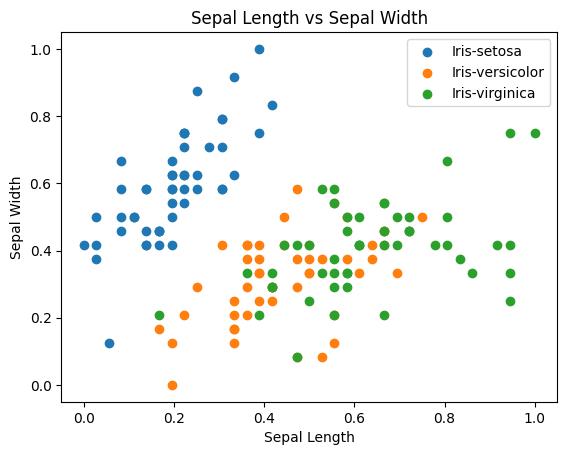

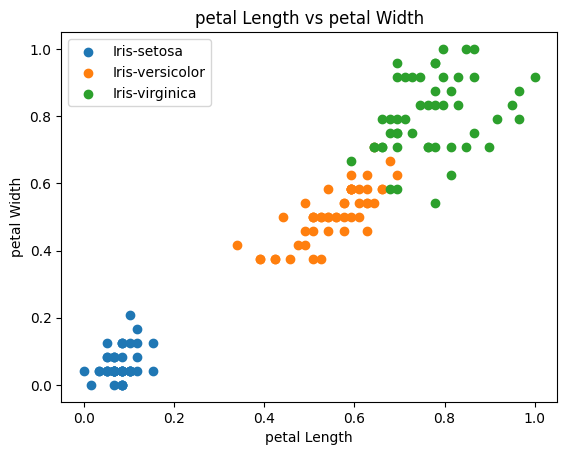

(None, None)

In [14]:
plot_sepal(X, y), plot_petal(X, y)

3. Data Splitting:  
   - Training set: 80% of the data (randomly selected while preserving class proportions – stratified sampling).  
   - Test set: the remaining 20%.

80/20 split

In [15]:
data = pd.concat([X, y], axis=1)

# Stratified sampling
train = data.groupby("class", group_keys=False).apply(lambda x: x.sample(frac=0.8, random_state=456))
X_train = train.drop("class", axis=1)
y_train = pd.DataFrame(train["class"])

test = data.loc[~data.index.isin(train.index)]
X_test = test.drop("class", axis=1)
y_test = pd.DataFrame(test["class"])

In [16]:
y_train.value_counts()

class          
Iris-setosa        40
Iris-versicolor    40
Iris-virginica     40
Name: count, dtype: int64

In [17]:
y_test.value_counts()

class          
Iris-setosa        10
Iris-versicolor    10
Iris-virginica     10
Name: count, dtype: int64

In [18]:
X_train

,sepal length,sepal width,petal length,petal width
29,0.111111,0.500000,0.101695,0.041667
24,0.138889,0.583333,0.152542,0.041667
0,0.222222,0.625000,0.067797,0.041667
40,0.194444,0.625000,0.050847,0.083333
7,0.194444,0.583333,0.084746,0.041667
...,...,...,...,...
134,0.500000,0.250000,0.779661,0.541667
105,0.916667,0.416667,0.949153,0.833333
113,0.388889,0.208333,0.677966,0.791667
111,0.583333,0.291667,0.728814,0.750000


In [19]:
y_train

,class
29,Iris-setosa
24,Iris-setosa
0,Iris-setosa
40,Iris-setosa
7,Iris-setosa
...,...
134,Iris-virginica
105,Iris-virginica
113,Iris-virginica
111,Iris-virginica


In [20]:
X_test.head()

,sepal length,sepal width,petal length,petal width
15,0.388889,1.000000,0.084746,0.125000
25,0.194444,0.416667,0.101695,0.041667
27,0.250000,0.625000,0.084746,0.041667
28,0.250000,0.583333,0.067797,0.041667
37,0.166667,0.458333,0.084746,0.000000


In [21]:
y_test.head()

,class
15,Iris-setosa
25,Iris-setosa
27,Iris-setosa
28,Iris-setosa
37,Iris-setosa


10-cross validation

In [22]:
def get_cross_validation_data(X, y, group_number=1, cross_groups=10):
    group_len = len(X) // cross_groups

    indices = np.arange(len(X))

    start = (group_number - 1) * group_len
    end = (group_number) * group_len
    mask = (indices >= start) & (indices < end)

    return X[~mask], y[~mask], X[mask], y[mask]

4. Implementation of kNN:  
   - Implement the kNN algorithm, allowing the user to specify the parameter **k**.

In [23]:
from scipy.spatial import KDTree

In [24]:
def kNN(X_train, y_train, X_test, y_test, k=3):
    kd_tree = KDTree(X_train.values)
    predictions = []

    for test_point in X_test.values:
        _, nearest_indices = kd_tree.query(test_point, k=k)

        nearest_labels = y_train.iloc[nearest_indices]

        most_common_label = nearest_labels.value_counts().idxmax()
        predictions.append(most_common_label)

    predictions = np.array(predictions)

    accuracy = np.mean(predictions == y_test.values) * 100
    return accuracy, predictions

In [25]:
kNN(X_train, y_train, X_train, y_train, k=4)

(95.83333333333334,
 array([['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
     

In [26]:
kNN(X_train, y_train, X_test, y_test, k=7)

(100.0,
 array([['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-setosa'],
        ['Iris-versicolor'],
        ['Iris-versicolor'],
        ['Iris-versicolor'],
        ['Iris-versicolor'],
        ['Iris-versicolor'],
        ['Iris-versicolor'],
        ['Iris-versicolor'],
        ['Iris-versicolor'],
        ['Iris-versicolor'],
        ['Iris-versicolor'],
        ['Iris-virginica'],
        ['Iris-virginica'],
        ['Iris-virginica'],
        ['Iris-virginica'],
        ['Iris-virginica'],
        ['Iris-virginica'],
        ['Iris-virginica'],
        ['Iris-virginica'],
        ['Iris-virginica'],
        ['Iris-virginica']], dtype='<U15'))

5. Experiments and Evaluation:  
   - Calculate and display the **accuracy** on the training set. Test with different values of **k**.  
   - Implement **10-fold cross-validation** on the training set, reporting the **average accuracy** and **standard deviation** for different values of **k**.  
   - Compute and display the **accuracy** on the test set, testing with different values of **k**.  
   - Compare the results.

In [27]:
def one_fold_experiment(X, y, k, group_number, cross_groups):
    X_train, y_train, X_test, y_test = get_cross_validation_data(X, y, group_number=group_number, cross_groups=10)
    accuracy, predictions = kNN(X_train, y_train, X_test, y_test, k=k)
    print(f"Accuracy Fold {group_number}: {accuracy:2f}%")

    return accuracy

In [28]:
def cross_validation_experiments(k, cross_groups):
    # shuffle the cross-validation data before grouping! can be commented out
    df_shuffled = pd.concat([X, y], axis=1).sample(frac=1, random_state=42).reset_index(drop=True)
    X_shuffled = df_shuffled.drop("class", axis=1)
    y_shuffled = pd.DataFrame(df_shuffled["class"])

    accuracies = []
    for group_number in range(1, cross_groups + 1):
        accuracy = one_fold_experiment(X_shuffled, y_shuffled, k, group_number, cross_groups)
        accuracies.append(accuracy)

    average_accuracy = np.mean(accuracies)
    standard_deviation = np.std(accuracies)
    return average_accuracy, standard_deviation

In [29]:
def experiment(k=3, cross_groups=10):
    train_accuracy, train_predictions = kNN(X_train, y_train, X_train, y_train, k=k)
    print(f"1. Train set accuracy: \nAccuracy: {train_accuracy:2f}%\n")

    print(f"2. {cross_groups}-Fold Cross-Validation Results:")
    average_accuracy, standard_deviation = cross_validation_experiments(k, cross_groups)
    print(f"\nAverage Accuracy: {average_accuracy:2f}%\nStandard Deviation: {standard_deviation:2f}\n")

    test_accuracy, test_predictions = kNN(X_train, y_train, X_test, y_test, k=k)
    print(f"3. Test set accuracy: \nAccuracy: {test_accuracy:2f}%\n")

    return train_accuracy, average_accuracy, standard_deviation, test_accuracy

In [30]:
averages = {}
for k in range(2, 30):
    _, average, _, _ = experiment(k=k, cross_groups=10)
    averages[k] = average

averages_df = pd.DataFrame.from_dict(averages, orient="index", columns=["Average Accuracy"])

1. Train set accuracy: 
Accuracy: 96.666667%

2. 10-Fold Cross-Validation Results:
Accuracy Fold 1: 100.000000%
Accuracy Fold 2: 100.000000%
Accuracy Fold 3: 100.000000%
Accuracy Fold 4: 93.333333%
Accuracy Fold 5: 100.000000%
Accuracy Fold 6: 93.333333%
Accuracy Fold 7: 80.000000%
Accuracy Fold 8: 100.000000%
Accuracy Fold 9: 100.000000%
Accuracy Fold 10: 93.333333%

Average Accuracy: 96.000000%
Standard Deviation: 6.110101

3. Test set accuracy: 
Accuracy: 100.000000%

1. Train set accuracy: 
Accuracy: 95.833333%

2. 10-Fold Cross-Validation Results:
Accuracy Fold 1: 100.000000%
Accuracy Fold 2: 100.000000%
Accuracy Fold 3: 100.000000%
Accuracy Fold 4: 93.333333%
Accuracy Fold 5: 100.000000%
Accuracy Fold 6: 93.333333%
Accuracy Fold 7: 80.000000%
Accuracy Fold 8: 100.000000%
Accuracy Fold 9: 100.000000%
Accuracy Fold 10: 93.333333%

Average Accuracy: 96.000000%
Standard Deviation: 6.110101

3. Test set accuracy: 
Accuracy: 100.000000%

1. Train set accuracy: 
Accuracy: 95.833333%

2.

<Axes: >

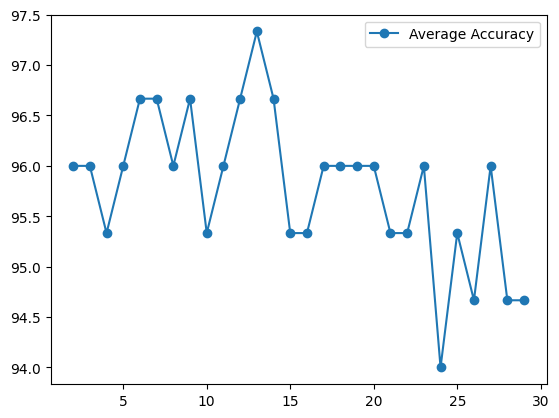

In [31]:
averages_df.plot(style="o-")

6. Results (Program Output)  

   For a given value of **k**, display:  
   - **Accuracy** on the training set for the standard split.  
   - **Average Accuracy** from **10-fold cross-validation**.  
   - **Accuracy** on the test set.

In [32]:
experiment(k=13)

1. Train set accuracy: 
Accuracy: 97.500000%

2. 10-Fold Cross-Validation Results:
Accuracy Fold 1: 100.000000%
Accuracy Fold 2: 100.000000%
Accuracy Fold 3: 100.000000%
Accuracy Fold 4: 93.333333%
Accuracy Fold 5: 100.000000%
Accuracy Fold 6: 100.000000%
Accuracy Fold 7: 86.666667%
Accuracy Fold 8: 100.000000%
Accuracy Fold 9: 100.000000%
Accuracy Fold 10: 93.333333%

Average Accuracy: 97.333333%
Standard Deviation: 4.422166

3. Test set accuracy: 
Accuracy: 96.666667%



(97.5, 97.33333333333334, 4.422166387140533, 96.66666666666667)